# 02 · Fraud Pattern Analysis

Describe rarity and temporal variation before building a model, while avoiding causal claims from synthetic data.

## Reading guide

This notebook is part of a connected workflow. It states the decision being made, shows the supporting checks and records limitations alongside the result. Source files are never modified in place.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_ROOT = Path(os.environ.get("FIFAR_DATA_DIR", PROJECT_ROOT / "data" / "raw" / "FiFAR"))
REPORTS = PROJECT_ROOT / "reports"
IMAGES = PROJECT_ROOT / "images"

sns.set_theme(style="whitegrid")
CORAL = "#F08FA0"
TEAL = "#0E6268"
DARK = "#15262B"

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        "Set FIFAR_DATA_DIR to the extracted official FiFAR directory before running this notebook."
    )

In [2]:
base = pd.read_csv(DATA_ROOT / 'alert_data' / 'Base.csv').dropna().copy()

## 1. Class balance

In [3]:
base['fraud_bool'].value_counts().rename(index={0: 'Legitimate', 1: 'Fraud'}).to_frame('applications')

,applications
fraud_bool,
Legitimate,906144
Fraud,11029


In [4]:
fraud_rate = base["fraud_bool"].mean()
print(f"Observed fraud rate: {fraud_rate:.2%}")
print(f"A classifier predicting every case as legitimate would be {1-fraud_rate:.2%} accurate and operationally useless.")

Observed fraud rate: 1.20%
A classifier predicting every case as legitimate would be 98.80% accurate and operationally useless.


## 2. Change over source months

In [5]:
month_profile = base.groupby("month")["fraud_bool"].agg(applications="size", fraud_cases="sum", fraud_rate="mean")
month_profile.drop(index=4).assign(fraud_rate=lambda frame: (frame["fraud_rate"] * 100).round(2))

,applications,fraud_cases,fraud_rate
month,,,
0.0,132440,1500,1.13
1.0,127620,1198,0.94
2.0,136979,1198,0.87
3.0,150936,1392,0.92
5.0,119323,1411,1.18
6.0,108168,1450,1.34
7.0,96843,1428,1.47


Month 4 is shown only in the data-quality notebook. It is removed here because the source file is incomplete during that period.

## 3. Numeric feature contrasts

In [6]:
numeric = [
    "name_email_similarity", "days_since_request", "credit_risk_score",
    "proposed_credit_limit", "session_length_in_minutes", "velocity_24h",
]
contrasts = base.groupby("fraud_bool")[numeric].median().T
contrasts.columns = ["legitimate_median", "fraud_median"]
contrasts["difference"] = contrasts["fraud_median"] - contrasts["legitimate_median"]
contrasts

,legitimate_median,fraud_median,difference
name_email_similarity,0.494958,0.292420,-0.202538
days_since_request,0.015249,0.013094,-0.002155
credit_risk_score,121.000000,178.000000,57.000000
proposed_credit_limit,200.000000,500.000000,300.000000
session_length_in_minutes,5.136223,5.121820,-0.014402
velocity_24h,4763.111181,4665.725851,-97.385330


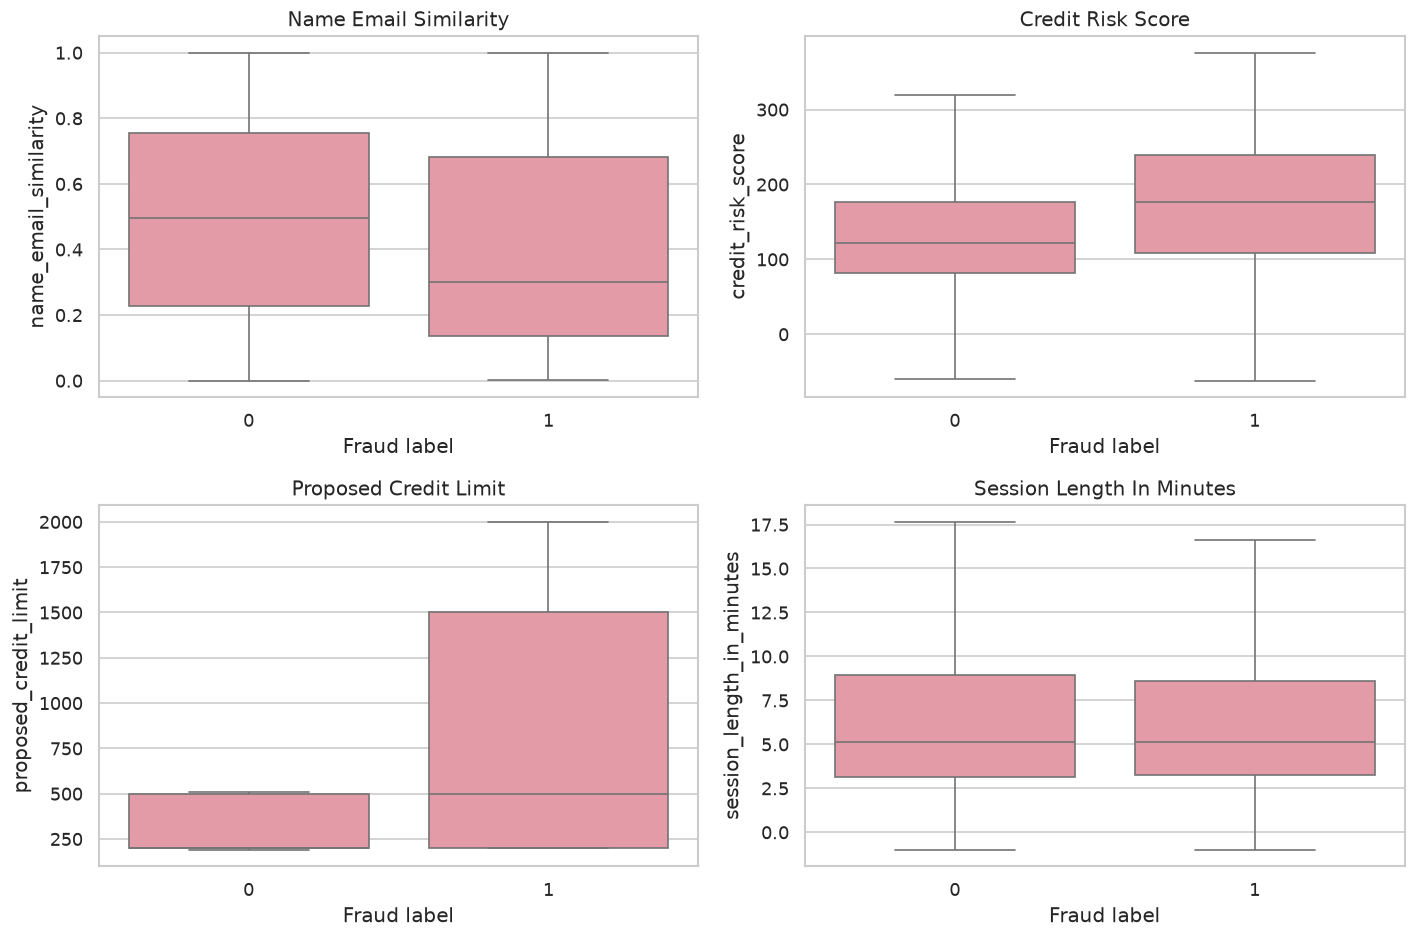

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, column in zip(axes.ravel(), ["name_email_similarity", "credit_risk_score", "proposed_credit_limit", "session_length_in_minutes"]):
    sample = base.sample(min(120_000, len(base)), random_state=42)
    sns.boxplot(data=sample, x="fraud_bool", y=column, ax=axis, color=CORAL, showfliers=False)
    axis.set(xlabel="Fraud label", title=column.replace("_", " ").title())
plt.tight_layout()
plt.show()

The plots describe association, not cause. The records are synthetic and several variables are encoded or normalised, so values should not be translated into real customer behaviour without documentation.

## 4. Categorical profiles

In [8]:
def category_profile(column):
    return base.groupby(column, observed=True)["fraud_bool"].agg(applications="size", fraud_cases="sum", fraud_rate="mean").sort_values("fraud_rate", ascending=False)

category_profile("device_os")

,applications,fraud_cases,fraud_rate
device_os,,,
windows,239270,6507,0.027195
macintosh,47801,752,0.015732
x11,6499,81,0.012463
other,315324,1974,0.006260
linux,308279,1715,0.005563


In [9]:
category_profile('payment_type')

,applications,fraud_cases,fraud_rate
payment_type,,,
AC,229332,4209,0.018353
AB,337817,4169,0.012341
AD,109001,1286,0.011798
AA,240758,1364,0.005665
AE,265,1,0.003774


In [10]:
category_profile('source')

,applications,fraud_cases,fraud_rate
source,,,
TELEAPP,6253,112,0.017911
INTERNET,910920,10917,0.011985


## 5. Sentinel values

In [11]:
sentinel_columns = ["prev_address_months_count", "current_address_months_count", "bank_months_count", "device_fraud_count"]
pd.DataFrame({
    "sentinel_minus_one": [(base[c] == -1).sum() for c in sentinel_columns],
    "share": [(base[c] == -1).mean() for c in sentinel_columns],
}, index=sentinel_columns)

,sentinel_minus_one,share
prev_address_months_count,653166,0.712151
current_address_months_count,3906,0.004259
bank_months_count,230882,0.251732
device_fraud_count,0,0.000000


**Modelling implication.** Sentinel values remain distinct. Median imputation is reserved for genuine missing values and is fitted only on the training months.

## Conclusion

Fraud is rare, changes across time and is associated with several application and device characteristics. Those patterns justify temporal validation and capacity-based metrics, but not causal interpretation.